## Import the data from the files

In [1]:
import numpy as np
import pandas as pd

In [2]:
# Load .npy files
Input_data = np.load('initial_inputs.npy')
Output_data = np.load('initial_outputs.npy')

In [3]:
# Convert to CSV
df = pd.DataFrame(Input_data, columns=['Feature_1', 'Feature_2'])
df['Output'] = Output_data

In [4]:
# Save to CSV
df.to_csv('model_data.csv', index=False)

In [5]:
# Verify
print("Data converted to CSV!")
print(df.head())

Data converted to CSV!
   Feature_1  Feature_2    Output
0   0.665800   0.123969  0.538996
1   0.877791   0.778628  0.420586
2   0.142699   0.349005 -0.065624
3   0.845275   0.711120  0.293993
4   0.454647   0.290455  0.214965


## Data Splitting

In [6]:
from sklearn.model_selection import train_test_split
import pandas as pd

In [7]:
# Load your dataset
data = pd.read_csv('model_data.csv')

In [8]:
# Check what columns exist
print(data.columns)

Index(['Feature_1', 'Feature_2', 'Output'], dtype='object')


In [9]:
#Split data between Features and Target
X = data[['Feature_1', 'Feature_2']]  # Features
y = data['Output'] # Target

In [10]:
# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Step 2: Model Training

### Linear Regression

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

LinearRegression()

In [12]:
# Predictions
linear_predictions = linear_model.predict(X_test)

In [13]:
### Random Forest

In [14]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [15]:
# Predictions
rf_predictions = random_forest_model.predict(X_test)

In [16]:
### Neural Network
from sklearn.neural_network import MLPRegressor

nn_model = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
nn_model.fit(X_train, y_train)

# Predictions
nn_predictions = nn_model.predict(X_test)

In [17]:
## Step 3: Evaluation Metrics
# Calculating metrics for Linear Regression
lin_mse = mean_squared_error(y_test, linear_predictions)
lin_r2 = r2_score(y_test, linear_predictions)
lin_mae = mean_absolute_error(y_test, linear_predictions)

# Calculating metrics for Random Forest
rf_mse = mean_squared_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)
rf_mae = mean_absolute_error(y_test, rf_predictions)

# Calculating metrics for Neural Network
nn_mse = mean_squared_error(y_test, nn_predictions)
nn_r2 = r2_score(y_test, nn_predictions)
nn_mae = mean_absolute_error(y_test, nn_predictions)

In [18]:
# Calculate metrics for each model
metrics = {
    'Model': ['Linear Regression', 'Random Forest', 'Neural Network'],
    'MSE': [lin_mse, lin_r2, lin_mae],
    'R² Score': [lin_r2, rf_r2, nn_r2],
    'MAE': [lin_mae, rf_mae, nn_mae]
        }

# Create DataFrame
metrics_df = pd.DataFrame(metrics)

# Display the table
print(metrics_df)

               Model       MSE  R² Score       MAE
0  Linear Regression  0.011351  0.759441  0.105260
1      Random Forest  0.759441  0.804852  0.095769
2     Neural Network  0.105260  0.412908  0.142465


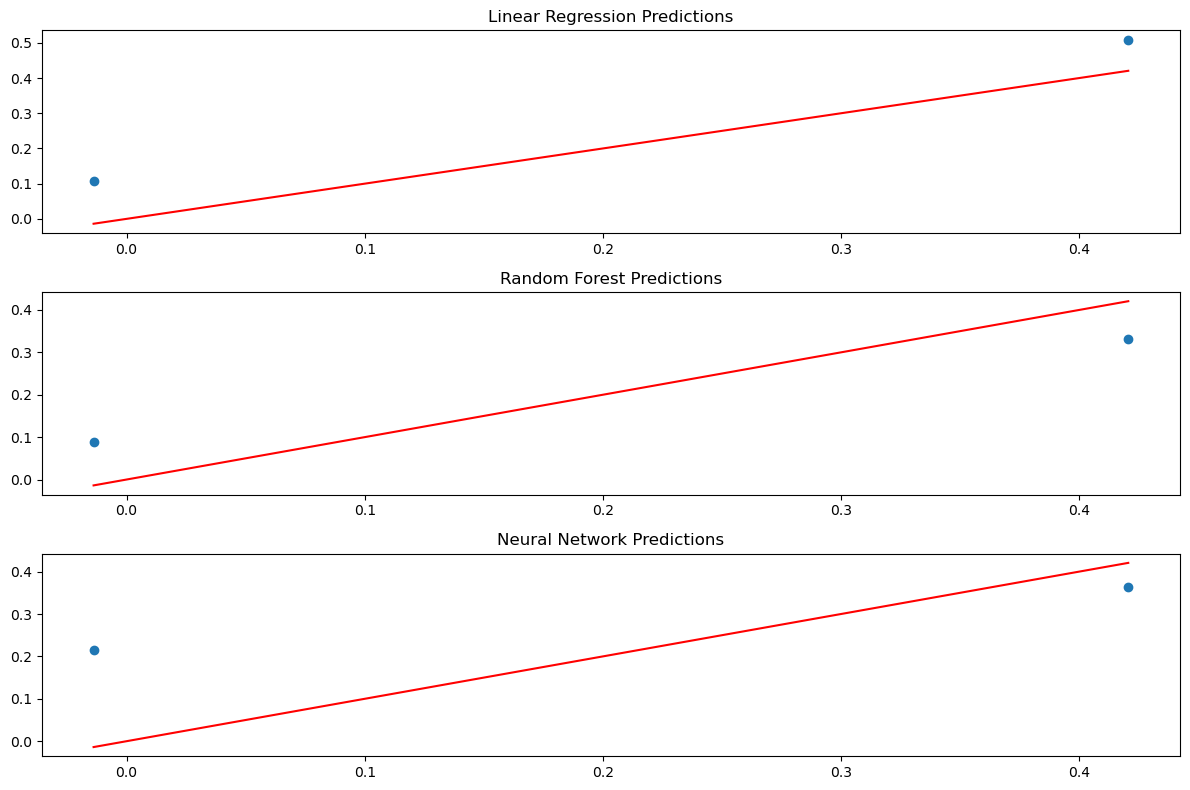

In [19]:
## Step 4: Visualizations
import matplotlib.pyplot as plt
import numpy as np

# Visualizing predictions
plt.figure(figsize=(12, 8))
plt.subplot(3, 1, 1)
plt.scatter(y_test, linear_predictions)
plt.plot(y_test, y_test, color='red')
plt.title('Linear Regression Predictions')

plt.subplot(3, 1, 2)
plt.scatter(y_test, rf_predictions)
plt.plot(y_test, y_test, color='red')
plt.title('Random Forest Predictions')

plt.subplot(3, 1, 3)
plt.scatter(y_test, nn_predictions)
plt.plot(y_test, y_test, color='red')
plt.title('Neural Network Predictions')

plt.tight_layout()
plt.show()

In [20]:
## Summary
#In this notebook, we implemented three machine learning models to predict `Output_data` from `Input_data`.
# We evaluated each model using metrics like MSE, R2 Score, and MAE, and visualized the model performance.